# 02 · A baseline triage model

Stage 2 of the *MLOps + AIOps on AWS* series. Can we tell, when a request comes in,
whether it will take longer than its category normally does?

This notebook trains the baseline **locally** on the Stage 1 snapshot, so every number is
reproducible at no cost. The same model then runs as a SageMaker Training Job (last
section) once the account's training quota is approved.

**The label** (`src/features/build_labels.py`): a request *breaches* if it takes longer
than its category's 75th percentile, computed on the training years only. That's a proxy,
not a City-published service standard. Two details keep it honest:

- **Censoring.** An open request already older than its threshold is a certain breach and
  is labelled late; one still inside its threshold has no label yet and is left out.
  Dropping every open request would make the most recent months look artificially fast.
- **Backlog purges.** Tickets closed in bulk cleanups keep their label but don't count
  towards the thresholds (D-034, D-037).

**The features** are only what's known at intake: category, agency, community, channel,
calendar, and recent backlog. Nothing from `closed_date`, `updated_date` or the status.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # run from code/notebooks/
from src.features.build_labels import build_training_labels

# The frozen snapshot from Stage 1. To recreate it without the API:
#   python -m src.ingest.socrata_pull replay --asof 2026-09-23
raw = pd.read_parquet("../data/processed/311").drop(columns=["year", "month"])
req = pd.to_datetime(raw["requested_date"], utc=True, format="ISO8601").dt.tz_localize(None)
print(f"{len(raw):,} requests, {req.min():%Y-%m-%d} to {req.max():%Y-%m-%d}")


2,911,486 requests, 2021-01-01 to 2026-09-22


In [2]:
# Chart style: one small set of tokens, reused by every figure in this series.
import matplotlib as mpl
import matplotlib.pyplot as plt

INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
POLE_UP, POLE_DOWN = "#e34948", "#2a78d6"  # diverging pair (red / blue)
SOURCE = "Data: City of Calgary 311 Service Requests, Open Government Licence – City of Calgary"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True,  # gridlines behind bars
    "lines.linewidth": 2, "legend.frameon": False,
})

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


def finish(fig, title, subtitle, name):
    """Left-aligned title and subtitle, a source line, then save a Medium-width PNG."""
    fig.text(0.01, 0.985, title, ha="left", va="top", fontsize=14, weight="bold", color=INK)
    fig.text(0.01, 0.925, subtitle, ha="left", va="top", fontsize=10, color=INK_2)
    fig.text(0.01, 0.01, SOURCE, ha="left", va="bottom", fontsize=7.5, color=MUTED)
    fig.savefig(FIGURES / name, dpi=200)
    plt.show()


In [3]:
from src.features.build_features import align_categories, build_features
from src.features.build_labels import assert_no_leakage

train, test, thresholds = build_training_labels(raw)
X_train = build_features(train, keep_key=False)
# categories the model never saw (3.1% of the test year) become missing; XGBoost handles that
X_test = align_categories(build_features(test, keep_key=False), X_train)
assert_no_leakage(X_train)
assert_no_leakage(X_test)
y_train, y_test = train["breach"].to_numpy(), test["breach"].to_numpy()

print(f"train {len(y_train):,} requests to {pd.to_datetime(train['requested_date'], utc=True, format='ISO8601').max():%Y-%m-%d}, "
      f"{y_train.mean():.1%} late")
print(f"test  {len(y_test):,} requests (the most recent year), {y_test.mean():.1%} late")
print(f"late-but-still-open requests labelled from censoring: {train['censored'].sum():,} train, {test['censored'].sum():,} test")

train 2,058,445 requests to 2025-09-21, 22.9% late
test  476,613 requests (the most recent year), 18.1% late
late-but-still-open requests labelled from censoring: 38,233 train, 13,378 test


In [4]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score

model = xgb.XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", enable_categorical=True, max_cat_to_onehot=1,
    eval_metric="aucpr", n_jobs=-1, random_state=42,
)
model.fit(X_train, y_train)
p = model.predict_proba(X_test)[:, 1]

base = y_test.mean()
top = p >= np.quantile(p, 0.9)
print(f"ROC-AUC {roc_auc_score(y_test, p):.3f}   PR-AUC {average_precision_score(y_test, p):.3f} (base rate {base:.3f})")
print(f"top 10% flagged: {y_test[top].mean():.1%} run late vs {base:.1%} overall -> {y_test[top].mean() / base:.2f}x lift; "
      f"catches {y_test[top].sum() / y_test.sum():.1%} of all late requests")

ROC-AUC 0.661   PR-AUC 0.316 (base rate 0.181)
top 10% flagged: 35.4% run late vs 18.1% overall -> 1.96x lift; catches 19.6% of all late requests


## The number that matters for triage

A triage tool doesn't need to be right about every request; it needs its short list to be
worth a second look. Split the test year into ten equal groups by predicted risk and ask
how often each group actually ran late.

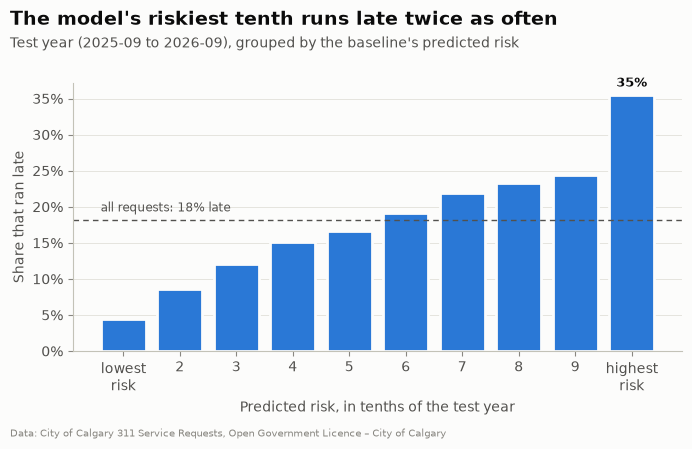

1      4.5
2      8.6
3     12.0
4     15.1
5     16.7
6     19.2
7     21.9
8     23.4
9     24.4
10    35.4
dtype: float64

In [5]:
decile = pd.qcut(pd.Series(p).rank(method="first"), 10, labels=range(1, 11))
by_decile = pd.Series(y_test).groupby(decile, observed=True).mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.4))
fig.subplots_adjust(left=0.1, right=0.97, top=0.82, bottom=0.21)
ax.bar(by_decile.index.astype(int), by_decile.values, color=SERIES[0], width=0.8, edgecolor=SURFACE, linewidth=2)
ax.axhline(base * 100, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.text(0.6, base * 100 + 0.8, f"all requests: {base:.0%} late", color=INK_2, fontsize=8.5, va="bottom")
top_rate = by_decile.iloc[-1]
ax.text(10, top_rate + 0.8, f"{top_rate:.0f}%", ha="center", va="bottom", color=INK, fontsize=9, weight="bold")
ax.set_xticks(range(1, 11), ["lowest\nrisk"] + [str(i) for i in range(2, 10)] + ["highest\nrisk"])
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
ax.set_ylabel("Share that ran late")
ax.set_xlabel("Predicted risk, in tenths of the test year")
finish(fig, "The model's riskiest tenth runs late twice as often",
       "Test year (2025-09 to 2026-09), grouped by the baseline's predicted risk", "02-late-by-risk-decile.png")
by_decile.round(1)

In [6]:
gain = pd.Series(model.get_booster().get_score(importance_type="gain"))
(gain / gain.sum()).sort_values(ascending=False).round(3).rename("share of gain")

service_name           0.226
cat_open_30d           0.134
req_month              0.125
agency_responsible     0.119
req_dow                0.106
req_is_holiday_week    0.092
source                 0.078
comm_name              0.074
req_is_weekend         0.030
comm_req_30d           0.015
Name: share of gain, dtype: float64

**Reading it honestly.** ROC-AUC is modest, and that's expected: most of what makes a
request slow isn't known at intake. The useful number is the lift: the riskiest tenth
runs late about twice as often as requests overall. The exploratory pass on a 230k-row
sample suggested 2.8×; on the full data it's about 2×, which is the number the series
uses (D-037). That leaves the Stage 5 challenger model something real to beat.

Where it struggles says as much as where it works: property-tax inquiries under the "AT"
prefix are flagged far more often than they run late, and graffiti and long-grass
requests are rarely flagged at all. Those are drift and calibration questions for later
stages.

## On AWS: the same model as a SageMaker Training Job

*To be added when the account's SageMaker training quota is approved (support case open).*
The job will train on the same features in S3 on a spot `ml.m5.large`, with a maximum run
time and `tags=aws_tags()` so its cost shows up under the project tag (D-030, D-031). Its
metrics should match the local numbers above; any difference is a bug to explain.